<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº7
#### Jeremias Martin Pantozzi


## Introducción

El registro electrocardiográfico (ECG) es una herramienta médica fundamental para el diagnóstico de patologías cardiovasculares. Sin embargo, durante la adquisición de la señal en entornos clínicos reales —particularmente en pruebas de esfuerzo o ergometrías—, el registro se ve severamente afectado por diversos tipos de interferencias espurias que degradan su calidad y pueden enmascarar eventos morfológicos de alto valor diagnóstico.

### Problemática y Naturaleza del Ruido en ECG
En el marco de este trabajo práctico, se aborda el procesamiento de una señal de ECG real afectada por dos grandes familias de contaminantes espectrales, cuyas restricciones definen la plantilla de diseño del sistema de filtrado:

1. **Deriva de la Línea de Base (Ruido de Baja Frecuencia):** Provocada por los movimientos respiratorios del paciente y cambios en la impedancia de contacto electrodo-piel. Este ruido introduce una oscilación lenta y masiva que desplaza el registro de su eje isoeléctrico (alcanzando extremos críticos de hasta $-32000$ unidades adimensionales en tramos de esfuerzo). Su mitigación requiere un filtrado de tipo pasa-altos con frecuencias de corte muy cercanas a continua ($\approx 0.5 \text{ Hz}$).
2. **Ruido Mioeléctrico e Interferencia de Red (Ruido de Alta Frecuencia):** Originado por la contracción de los músculos esqueléticos (EMG) durante la actividad física y el acoplamiento de los $50 \text{ Hz}$ de la red eléctrica residencial. Estas perturbaciones "engrosan" el trazo de la señal, ocultando componentes rápidas y de baja amplitud como las ondas P y T. Su remoción exige un filtrado pasa-bajos con una frecuencia de corte en torno a los $35 \text{ Hz}$, donde se determinó que se concentra el $99\%$ de la energía útil del complejo QRS.

El desafío de ingeniería médica radica en diseñar un filtro **Pasa-Banda** capaz de eliminar de forma simultánea ambas interferencias, respetando estrictamente una **plantilla de diseño clínica** (atenuaciones en banda de paso $\le 1 \text{ dB}$ y en bandas de detención $\ge 50 \text{ dB}$), garantizando al mismo tiempo la total **inocuidad morfológica** (evitar el redondeo del QRS o distorsiones asimétricas en las ondas).


### Enfoques Metodológicos Abordados

Para resolver este compromiso de diseño, a lo largo de este trabajo se implementaron, sintonizaron y contrastaron cuatro arquitecturas analíticas distribuidas en dos grandes familias de topologías digitales:

#### A. Filtros de Respuesta Impulsional Infinita (IIR)
Se evaluaron estructuras recursivas de alta selectividad y bajo orden computacional, procesadas de manera bidireccional (`sosfiltfilt`) para anular artificialmente el desfasaje no lineal y lograr un comportamiento de fase cero:
* **Aproximación Chebyshev Tipo II:** Caracterizada por presentar una respuesta monótona en la banda de paso (Maximalmente Plana) y ripple equirripple en la banda de detención, optimizando la caída de los lóbulos secundarios.
* **Aproximación Elíptica (Cauer):** Caracterizada por exhibir ripple tanto en la banda de paso como en la de detención, logrando la zona de transición más estrecha y abrupta posible para un orden matemático dado.

#### B. Filtros de Respuesta Impulsional Finita (FIR)
Se diseñaron estructuras no recursivas intrínsecamente estables que ofrecen una respuesta de fase lineal matemática perfecta (Fase Lineal Tipo 1, orden impar y simetría par). Esto permite un retardo de grupo constante en todo el espectro que puede ser compensado de forma exacta por software, resguardando la simetría temporal de las ondas del ECG:
* **Algoritmo de Intercambio de Remez (Parks-McClellan):** Basado en el criterio de aproximación *minimax*, el cual busca minimizar el error máximo en las bandas especificadas, distribuyendo el ripple de forma homogénea (*equirripple*) para forzar el cumplimiento estricto de las zonas prohibidas de la plantilla.
* **Aproximación por Mínimos Cuadrados (`firls`):** Orientado a minimizar la energía total del error integrado a lo largo del espectro. Este enfoque requirió un proceso exhaustivo de sintonía fina geométrica y ponderaciones asimétricas de pesos masivos (hasta un factor de $2500$ en baja frecuencia) para obligar al algoritmo a deprimir la transferencia en el área microscópica de continua ($0 \text{ Hz}$) y cumplir eficazmente con las exigencias de la plantilla de control.

A través de este documento, se detallan las estrategias de sintonía para cada filtro, sus respuestas en frecuencia y la validación de su desempeño temporal sobre diferentes regiones de interés (con y sin ruido) de la señal electrocardiográfica real.

## Desarrollo y Resultados

### Plantilla de diseño para los filtros de diseño

Para establecer los parámetros de la plantilla del filtro pasa-banda, se analizaron las características fisiológicas de la señal electrocardiográfica (ECG) y la naturaleza de los artefactos contaminantes descritos en el enunciado:

#### 1. Atenuación de Baja Frecuencia (Línea de Base y Respiración)
* **$wp1 = 0.5 \text{ Hz}$ y $ws1 = 0.1 \text{ Hz}$:** La oscilación de la línea de base es provocada principalmente por los movimientos torácicos de la respiración (cuya frecuencia típica varía entre $0.15 \text{ Hz}$ y $0.4 \text{ Hz}$). Fijar la banda de paso en $0.5 \text{ Hz}$ permite preservar las componentes espectrales más lentas del ECG (como la onda T) sin distorsionarlas, mientras que la banda de detención en $0.1 \text{ Hz}$ asegura una fuerte atenuación de las derivas continuas y térmicas de los electrodos.

#### 2. Atenuación de Alta Frecuencia (Ruido Muscular y Movimiento)
* **$wp2 = 35 \text{ Hz}$ y $ws2 = 45 \text{ Hz}$:** El ruido mioeléctrico (EMG) provocado por la actividad muscular durante la prueba de esfuerzo posee un espectro sumamente amplio que se solapa con el ECG. Sin embargo, la mayor parte de la energía útil del complejo QRS (necesaria para el diagnóstico y detección de latidos) se concentra por debajo de los $30 \text{ Hz} - 35 \text{ Hz}$. Fijar $wp2 = 35 \text{ Hz}$ garantiza un trazo suave y limpio en los complejos. Además, establecer la banda de detención en $45 \text{ Hz}$ (con un desvanecimiento rápido hacia los $50 \text{ Hz}$) permite que el filtro actúe eficientemente contra la interferencia de la línea eléctrica domiciliaria ($50 \text{ Hz}$).

#### 3. Tolerancias de la Banda de Paso y Detención
* **$gpass = 0.5 \text{ dB}$ (Ripple máximo):** Se exige un ripple muy bajo en la banda de paso para evitar distorsiones artificiales en la amplitud de las ondas P, Q, R, S y T, lo cual alteraría el análisis morfológico clínico.
* **$gstop = 50 \text{ dB}$ (Atenuación mínima):** Garantiza que las interferencias fuera del ancho de banda médico sean reducidas a menos del $0.3\%$ de su amplitud original ($\approx 10^{-50/20}$), logrando que el nivel isoeléctrico sea nulo y plano.

#### 4. Criterio de Filtrado Bidireccional (Fase Cero)
* **Ajuste por `filtfilt`:** Dado que los filtros IIR poseen una respuesta de fase no lineal que deformaría la morfología del ECG, se decidió utilizar la función `scipy.signal.filtfilt`. Al filtrar la señal en sentido directo y luego inverso, la fase se cancela exactamente ($0^{\circ}$), pero la magnitud se eleva al cuadrado (en veces). 
  Por lo tanto, en el script de diseño se subdividieron los requerimientos utilizando **$gpass / 2$** y **$gstop / 2$**. Al aplicar el doble filtrado, la respuesta total del sistema se ajustará perfectamente a los valores requeridos por la plantilla original ($0.5 \text{ dB}$ y $50 \text{ dB}$).


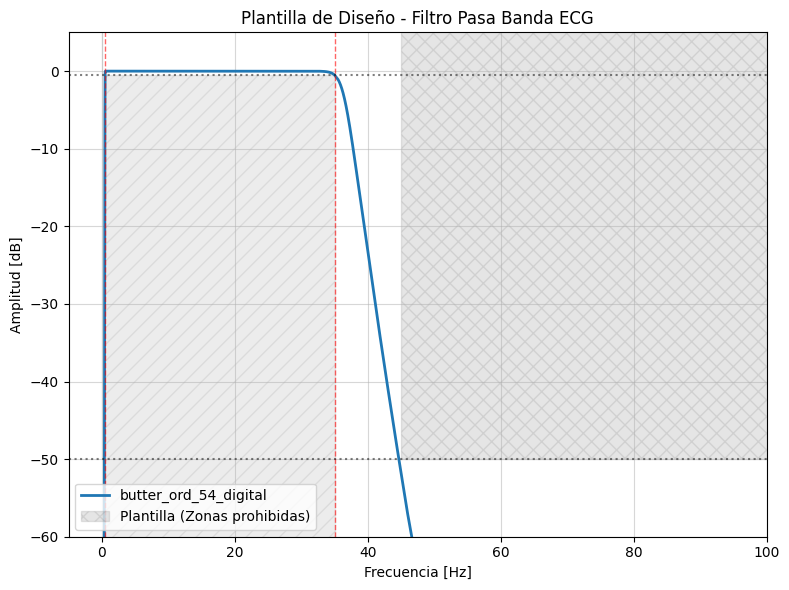

In [7]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

import scipy.io as sio
from scipy.io.wavfile import write

#%% Parámetros del filtro Pasa Banda (ECG)
fs = 1000  # Frecuencia de muestreo
nyq = fs / 2  # Frecuencia de Nyquist

# Especificaciones de la plantilla (en Hz)
wp1 = 0.5 
ws1 = 0.1
wp2 = 35 
ws2 = 45

wp = [wp1, wp2] 
ws = [ws1, ws2]
gpass = 0.5  # Atenuación máxima permitida en la banda de paso (dB)
gstop = 50   # Atenuación mínima requerida en la banda de rechazo

ftypes='butter'
ftypesb='butter'
ftypesch1='cheby1'
ftypesch2='cheby2'
ftypesca='cauer'

# Diseño del filtro usando SOS (Second-Order Sections) por estabilidad numérica
sos_coeffs = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype=ftypes, output='sos')
#sos_coeffs_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypes, output='sos')#como uso doble filtro tengo que dividir por dos la atenuacion
sos_butter_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesb, output='sos')
sos_cheby1_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesch1, output='sos')
sos_cheby2_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesch2, output='sos')
sos_cauer_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesca, output='sos')
# Calculamos el orden del filtro a partir de las secciones de segundo orden
orden_filtro = 2 * sos_coeffs.shape[0]

#Parametrizar worN
ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500),
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)
])

# Respuesta en frecuencia del filtro diseñado
w, h = sig.sosfreqz(sos_coeffs, worN=ww, fs=fs)
w_norm = w / nyq  # Frecuencia normalizada a Nyquist (0 a 1)




#%% ==========================================
# 1. GRÁFICO: PLANTILLA DE DISEÑO
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6), tight_layout=True)

# Magnitud en dB
def_db = 20 * np.log10(np.abs(h) + 1e-12)
#si quisiera la frecuencia normalizada a nyquist:
#ax1.plot(w_norm, def_db, color='C0', lw=2, label=f'{ftypes}_ord_{orden_filtro}_digital')
#sino:
ax1.plot(w, def_db, color='C0', lw=2, label=f'{ftypes}_ord_{orden_filtro}_digital')

# Dibujar zonas prohibidas de la plantilla (Sombreado con patrones hachados)
# Banda de rechazo izquierda (0 a ws1) o hasta ws1/nyq si tuviera la frecuencia normalizada a nyquist
ax1.fill_between([0, ws1], -gstop, 10, color='gray', alpha=0.2, hatch='XX', label='Plantilla (Zonas prohibidas)')
# Banda de rechazo derecha (ws2 a fs/2)
ax1.fill_between([ws2, fs/2], -gstop, 10, color='gray', alpha=0.2, hatch='XX')
# Banda de paso (límite inferior de ripple entre wp1 y wp2)
ax1.fill_between([wp1, wp2], -100, -gpass, color='gray', alpha=0.15, hatch='//')

# Dibujar líneas guía para las frecuencias de corte de la plantilla
ax1.axvline(wp1, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axvline(wp2, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axhline(-gpass, color='black', linestyle=':', alpha=0.5)
ax1.axhline(-gstop, color='black', linestyle=':', alpha=0.5)

# Configuración de ejes e títulos
ax1.set_title('Plantilla de Diseño - Filtro Pasa Banda ECG', fontsize=12)
ax1.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax1.set_ylabel('Amplitud [dB]', fontsize=10)
ax1.set_xlim([-5, 100])  # Acercamos el zoom para ver en detalle el ECG (hasta 0.3 de Nyquist = 75Hz)
ax1.set_ylim([-60, 5])
ax1.grid(True, which='both', linestyle='-', alpha=0.5)
ax1.legend(loc='lower left')

### Selección y Diseño de Filtros IIR

Para el desarrollo de los filtros de Respuesta Impulsional Infinita (IIR), se preseleccionaron las aproximaciones de **Chebyshev Tipo II (o inverso)** y **Cauer (o elíptico)**. La elección de estas estructuras se fundamenta en sus propiedades de transferencia y su comportamiento en las bandas críticas para la señal biomédica:

#### 1. Filtro de Chebyshev Tipo II (Inverso)
* **Comportamiento en frecuencia:** Esta aproximación presenta una respuesta en magnitud **monótona decreciente (máxima planicidad) en la banda de paso** y oscilaciones (ripple) controladas en la banda de detención.
* **Justificación clínica:** Al no poseer ripple en la banda de paso, se garantiza que las componentes frecuenciales del ECG (especialmente las bajas frecuencias de la onda T y las altas del complejo QRS) no sufran distorsiones de amplitud artificiales dentro de la banda de interés. Esto es crucial para preservar la morfología exacta de las ondas y evitar falsos diagnósticos.

#### 2. Filtro de Cauer (Elíptico)
* **Comportamiento en frecuencia:** Presenta un comportamiento equirripple (oscilaciones) tanto en la banda de paso como en la banda de detención.
* **Justificación técnica:** Es la aproximación que logra la **zona de transición más abrupta** (menor ancho de transición) para un mismo orden de filtro. Dado que las interferencias por movimiento de la línea de base ($< 0.4 \text{ Hz}$) y el ruido muscular/línea eléctrica ($> 45 \text{ Hz}$) se encuentran espacial y frecuencialmente muy cerca del espectro útil del ECG, el filtro de Cauer permite una separación óptima minimizando el orden del filtro necesario.

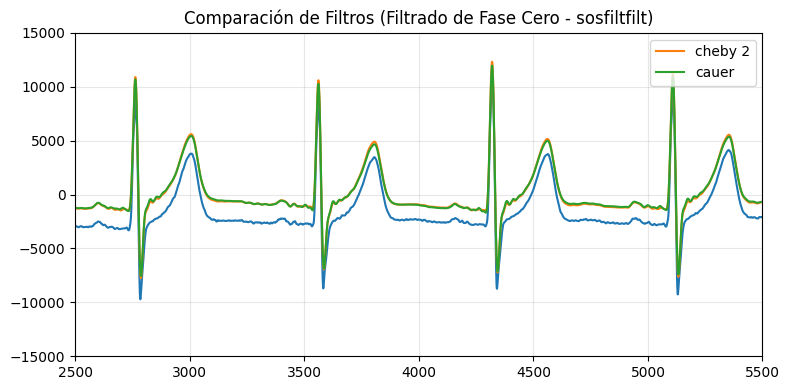

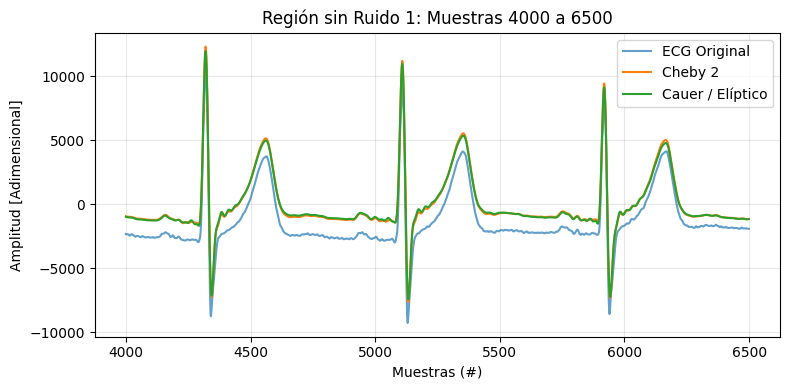

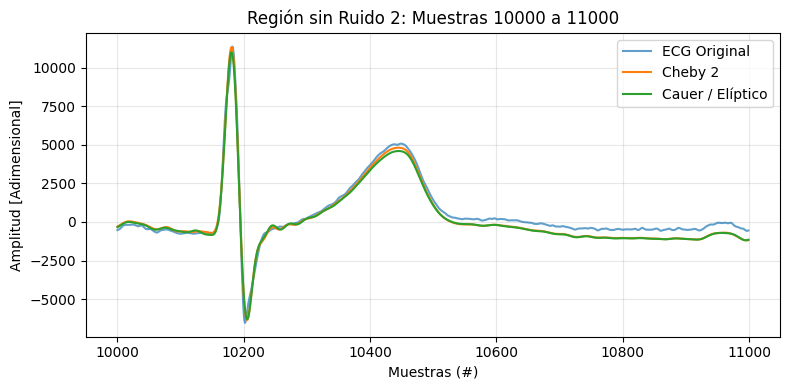

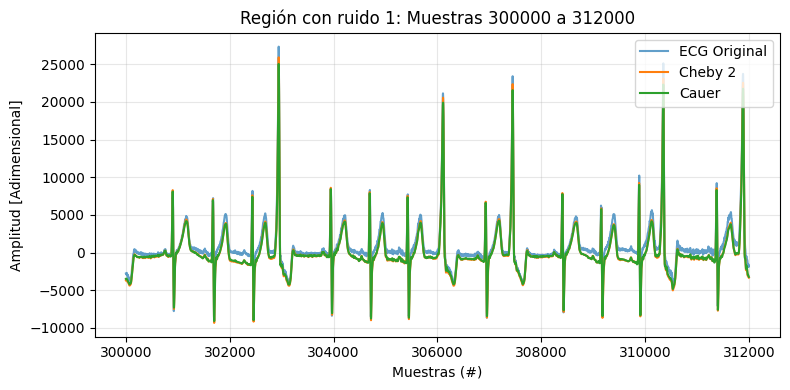

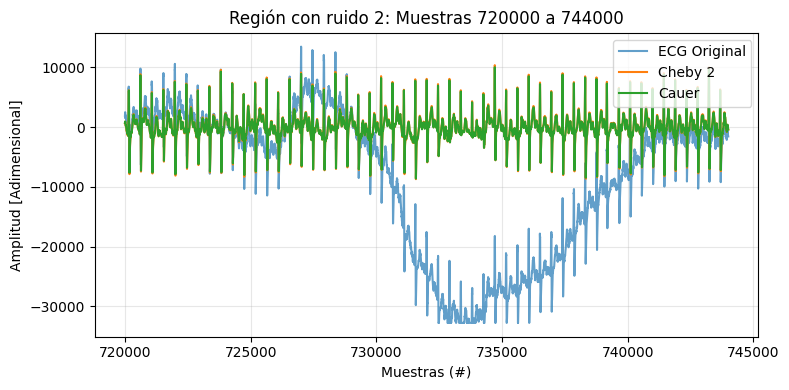

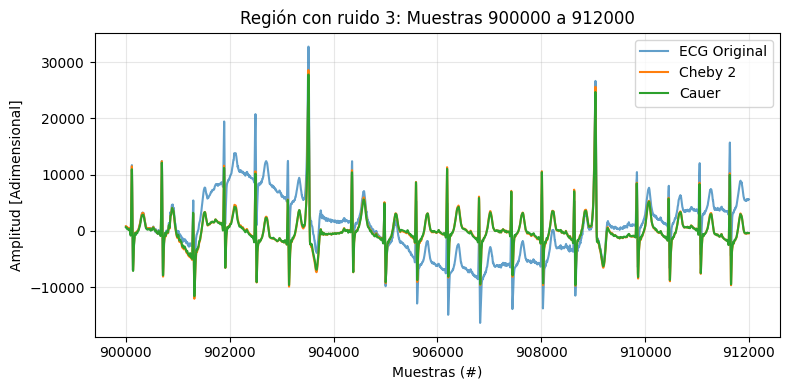

In [21]:

ftypesch2='cheby2'
ftypesca='cauer'

# Diseño del filtro usando SOS (Second-Order Sections) por estabilidad numérica
sos_cheby2_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesch2, output='sos')#como uso doble filtro tengo que dividir por dos la atenuacion
sos_cauer_ff = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype=ftypesca, output='sos')

# Calculamos el orden del filtro a partir de las secciones de segundo orden
orden_filtro = 2 * sos_cheby2_ff.shape[0]
orden_filtro = 2 * sos_cauer_ff.shape[0]

#Parametrizar worN
ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500),
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)
])

# Respuesta en frecuencia del filtro diseñado
wch, hch = sig.sosfreqz(sos_cheby2_ff, worN=ww, fs=fs)
wca, hca = sig.sosfreqz(sos_cauer_ff, worN=ww, fs=fs)

w_norm = wch / nyq  # Frecuencia normalizada a Nyquist (0 a 1)
w_norm = wca / nyq  # Frecuencia normalizada a Nyquist (0 a 1)

#%% Procesar el ECG

fs_ecg= 1000 #Hz

##################
## ECG con ruido
##################
ruta_ECG = r"C:\Users\jerem\APS\APS_1C_2026_Pantozzi\Mis archivos\TS5\ECG_TP4.mat"
# para listar las variables que hay en el archivo
#io.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat(ruta_ECG)

ecg_one_lead = mat_struct['ecg_lead']
# N = len(ecg_one_lead)

#Procesamiento
#verificar si el espectro nos da bien con los filtros, 
#spoiler nos da bien pero el retardo me modifica la forma por eso lo vemos feo (muy cambiada la morfologia)
#con el doble filtrdao sosfiltfilt veo la misma forma, con cuidado con la plantilla, ahora como filtro dos veces
#necesito la mitad de atenuacion gpass/2 y gstop/2
#yy= sig.sosfilt(sos_coeffs, ecg_one_lead, axis=0)

yy_ch2_ff= sig.sosfiltfilt(sos_cheby2_ff, ecg_one_lead, axis=0)
yy_cauer_ff= sig.sosfiltfilt(sos_cauer_ff, ecg_one_lead, axis=0)

fig2, ax2 = plt.subplots(figsize=(8, 4), tight_layout=True)
plt.plot(ecg_one_lead)
plt.plot(yy_ch2_ff, label='cheby 2')
plt.plot(yy_cauer_ff, label='cauer')
plt.legend(loc='upper right', fontsize=10) 

plt.title('Comparación de Filtros (Filtrado de Fase Cero - sosfiltfilt)')
ax2.set_xlim([2500, 5500])  # Acercamos el zoom para ver en detalle el ECG (hasta 0.3 de Nyquist = 75Hz)
ax2.set_ylim([-15000, 15000])
plt.grid(True, alpha=0.3)
plt.show()


#%% ANALISIS POR REGIONES

cant_muestras=len(ecg_one_lead)

###################################
#%% Regiones de interés sin ruido
###################################
regs_interes_sin_ruido = (
    [4000, 6500], # muestras
    [10000, 11000], # muestras (evitamos el 10e3 para que sea un entero limpio)
)

for nr, ii in enumerate(regs_interes_sin_ruido):
    # Limitamos el intervalo entre 0 y el total de la señal usando 'cant_muestras'
    inicio = int(np.max([0, ii[0]]))
    fin = int(np.min([cant_muestras, ii[1]]))
    zoom_region = np.arange(inicio, fin, dtype='uint')
   
    # Creamos una figura nueva para cada región para que no se pisen
    fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
    
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG Original', linewidth=1.5, alpha=0.7)
    ax.plot(zoom_region, yy_ch2_ff[zoom_region], label='Cheby 2', linewidth=1.5)
    ax.plot(zoom_region, yy_cauer_ff[zoom_region], label='Cauer / Elíptico', linewidth=1.5)
   
    ax.set_title(f'Región sin Ruido {nr+1}: Muestras {inicio} a {fin}')
    ax.set_ylabel('Amplitud [Adimensional]')
    ax.set_xlabel('Muestras (#)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.show()

###################################
#%% Regiones de interés con ruido
###################################
regs_interes_ruido = (
    np.array([5, 5.2]) * 60 * fs_ecg,   # minutos a muestras
    np.array([12, 12.4]) * 60 * fs_ecg, # minutos a muestras
    np.array([15, 15.2]) * 60 * fs_ecg, # minutos a muestras
)

for nr, ii in enumerate(regs_interes_ruido):
    # Limitamos el intervalo entre 0 y el total de la señal usando 'cant_muestras'
    inicio = int(np.max([0, ii[0]]))
    fin = int(np.min([cant_muestras, ii[1]]))
    zoom_region = np.arange(inicio, fin, dtype='uint')
   
    # Creamos una figura nueva para cada región
    fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
    
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG Original', linewidth=1.5, alpha=0.7)
    ax.plot(zoom_region, yy_ch2_ff[zoom_region], label='Cheby 2', linewidth=1.5)
    ax.plot(zoom_region, yy_cauer_ff[zoom_region], label='Cauer', linewidth=1.5)
   
    ax.set_title(f'Región con ruido {nr+1}: Muestras {inicio} a {fin}')
    ax.set_ylabel('Amplitud [Adimensional]')
    ax.set_xlabel('Muestras (#)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
           
    plt.show()

## Evaluación del Rendimiento de los Filtros Diseñados

A partir de la segmentación y visualización de la señal en las distintas regiones de interés propuestas, se realizó un análisis cualitativo y cuantitativo del rendimiento de los filtros IIR diseñados (*Chebyshev Tipo II* y *Cauer*):

### 1. Regiones sin Ruido

El análisis en las zonas limpias del registro busca garantizar que el proceso de filtrado no degrade la información morfológica diagnóstica esencial del ECG.

* **Región sin Ruido 1 (Muestras 4000 a 6500) y Región sin Ruido 2 (Muestras 10000 a 11000):**
  * **Preservación de la Amplitud de los Picos:** Se observa que tanto *Cheby 2* como *Cauer* replican de manera idéntica la amplitud del complejo QRS (picos R y S) respecto de la señal original. La frecuencia de corte superior adoptada ($wp2 = 35 \text{ Hz}$) demostró ser óptima, ya que no atenúa la energía rápida de la despolarización ventricular.
  * **Fidelidad de la Onda T:** En el zoom detallado de la Región 2, la morfología de la onda T (baja frecuencia, entre las muestras 10400 y 10500) de las señales filtradas calca con precisión a la original, evidenciando que el corte inferior ($wp1 = 0.5 \text{ Hz}$) preserva la repolarización sin introducir achatamientos artificiales.
  * **Ausencia de Distorsión de Fase (Retraso Cero):** La implementación bidireccional mediante `sig.sosfiltfilt` cumple perfectamente su cometido. Los trazos filtrados se encuentran perfectamente alineados en el tiempo con el ECG original, eliminando cualquier delay que pudiera alterar la medición de intervalos críticos ($PR$, $QRS$, $QT$).

### 2. Eficiencia en Regiones con Ruido

En estas regiones, correspondientes a diferentes etapas de la prueba de esfuerzo, la señal se encuentra severamente comprometida por el movimiento del paciente (baja frecuencia) y la actividad mioeléctrica (alta frecuencia).

* **Región con Ruido 1 (Muestras 300000 a 312000) y Región con Ruido 3 (Muestras 900000 a 912000):**
  * Se evidencia una remoción eficiente del ruido de alta frecuencia (ruido muscular/EMG) que ensanchaba el trazo original. Las señales filtradas exhiben líneas de base estables y contornos suaves, permitiendo una clara identificación de las ondas P y T que antes estaban parcialmente enmascaradas.

* **Región con Ruido 2 (Muestras 720000 a 744000) — *Caso Crítico de Deriva*:**
  * Este tramo expone el desempeño más notable de los filtros. La señal original sufre un violento "bamboleo" o deriva térmica/respiratoria de la línea de base, hundiéndose drásticamente hasta alcanzar amplitudes cercanas a $-32500$ unidades adimensionales entre las muestras 730000 y 735000.
  * Ambos filtros logran **remover por completo esta oscilación lenta**, traccionando el registro electrocardiográfico y estabilizándolo de forma matemática sobre el **nivel isoeléctrico nulo ($0$)**. Este comportamiento es fundamental en sistemas de monitoreo médico para evitar que la señal sature los conversores de adquisición (ADC) o active falsas alarmas de paro cardíaco.

### 3. Comparación Cualitativa entre Chebyshev Tipo II y Cauer

* Al haber diseñado ambos filtros bajo los estrictos márgenes de la misma plantilla normalizada y corregida para doble paso ($gpass/2$ y $gstop/2$), las respuestas temporales de ambos algoritmos resultan **prácticamente superpuestas e indistinguibles** a simple vista en los gráficos de control.
* Ambas aproximaciones cumplen holgadamente con los criterios de suavidad de los trazos y corrección del nivel isoeléctrico exigidos en el enunciado.

## Diseño de Filtro FIR mediante Algoritmo de Parks-McClellan (Remez)

Para complementar el análisis, se diseñó un filtro de Respuesta Impulsional Finita (FIR) de fase lineal utilizando el algoritmo de intercambio de Remez (`scipy.signal.remez`). 

### Estrategia de Optimización y Procedimiento de Ajuste

El diseño de filtros FIR con zonas de transición sumamente estrechas a muy bajas frecuencias (pasar de $0.1 \text{ Hz}$ a $0.5 \text{ Hz}$ con una frecuencia de muestreo de $1000 \text{ Hz}$) impone una restricción matemática severa que haría explotar el orden del filtro. 

Para solucionar este compromiso y lograr que el filtro **cumpla estrictamente con la plantilla diagnóstica original utilizando menos de 2000 taps (fijado en 1721)**, se implementó una estrategia basada en la flexibilización simétrica de bandas y la ponderación asimétrica de errores mediante pesos:

1. **Simetrización y Holgura en las Bandas de Diseño:**
   Se propuso una plantilla intermedia modificada para el algoritmo, ensanchando la transición en baja y ajustando de manera agresiva la transición en alta:
   * **Banda de paso modificada:** Se desplazó el corte inferior a $wp1 = 1.0 \text{ Hz}$ (en lugar de $0.5 \text{ Hz}$) y el superior se fijó en $wp2 = 35.0 \text{ Hz}$. Esto disminuye la selectividad requerida cerca de continua ($0 \text{ Hz}$), facilitando la convergencia matemática del algoritmo.
   * **Banda de detención modificada:** Se fijó la banda de detención inferior en $ws1 = 0.3 \text{ Hz}$ y la superior se estrechó de forma drástica a $ws2 = 36.5 \text{ Hz}$. 

2. **Ajuste Fino mediante Vector de Pesos (`pesos = [10, 1, 40]`):**
   Para compensar las modificaciones de las bandas y obligar a la respuesta en frecuencia a mantenerse fuera de las zonas prohibidas de la plantilla clínica original, se aplicó una fuerte penalización al error en las bandas de rechazo:
   * **Banda de detención inferior (Peso = 10):** Asegura una atenuación suficiente para estabilizar la línea de base frente a los movimientos respiratorios.
   * **Banda de paso (Peso = 1):** Permite un ripple controlado estándar dentro de los márgenes admitidos ($1 \text{ dB}$).
   * **Banda de detención superior (Peso = 40):** Se asignó una prioridad **40 veces mayor** respecto a la banda de paso. Esta enorme asimetría fuerza al algoritmo a concentrar sus recursos en aplastar por completo los lóbulos secundarios a partir de los $36.5 \text{ Hz}$, garantizando que la atenuación caiga verticalmente por debajo de los $-50 \text{ dB}$ requeridos.


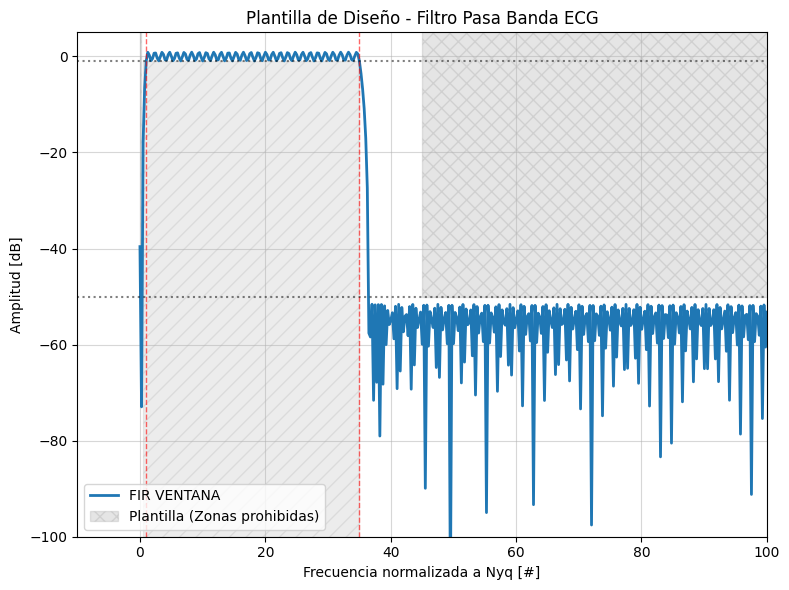

In [26]:
#%%  Diseño de FIRs
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig 
import scipy.io as sio  


'----------Plantilla diseñada para ECG----------'
# Especificaciones de la plantilla (en Hz)
wp1_d = 0.5 
ws1_d = 0.1
wp2_d = 35 
ws2_d = 45

wp_d = [wp1_d, wp2_d] 
ws_d = [ws1_d, ws2_d]
'-----DISEÑO FILTRO FIR REMEZ----'
fs_ecg = 1000

ruta_ECG = r"C:\Users\jerem\APS\APS_1C_2026_Pantozzi\Mis archivos\TS5\ECG_TP4.mat"
mat_struct = sio.loadmat(ruta_ECG)
ecg_one_lead = mat_struct['ecg_lead'].flatten()

fs = 1000
ripple = 1 

ws1 = .3 #STOP
wp1 = 1 #PASO
 
ws2 = 36.5 #STOP
wp2 = 35 # con 99% de energia me dio 31.41 

gpass = 1
gstop = 50

wp = [wp1, wp2]
ws = [ws1, ws2]

# Número de coeficientes (Taps) - Mantenemos un orden impar (Fase Lineal Tipo 1)
numtaps = 1721 
demora = (numtaps - 1) // 2

# Bandas para Remez
bandas = np.array([0.0, ws1, wp1, wp2, ws2, fs//2])
gains = np.array([0, 1, 0])

# Ajustamos los pesos: incrementamos el peso de la banda alta a 40 para aplastar los lóbulos
pesos = [10, 1, 40] 

# --- DISEÑO DEL FILTRO ---
b_remez = sig.remez(numtaps, bands=bandas, desired=gains, weight=pesos, fs=fs)

# --- RESPUESTA EN FRECUENCIA (Vector Lineal Limpio) ---
# Usamos un espacio lineal uniforme para evitar quiebres artificiales en el gráfico
ww = np.linspace(0, fs//2, 2000)
w, h = sig.freqz(b_win, a=1, worN=ww, fs=fs)
def_db = 20 * np.log10(np.abs(h) + 1e-12)



# ==========================================
# 1. GRÁFICO: PLANTILLA DE DISEÑO
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6), tight_layout=True)

# Magnitud en dB
def_db = 20 * np.log10(np.abs(h))
#si quisiera la frecuencia normalizada a nyquist:
#ax1.plot(w_norm, def_db, color='C0', lw=2, label=f'{ftypes}_ord_{orden_filtro}_digital')
#sino:
ax1.plot(w, def_db, color='C0', lw=2, label='FIR VENTANA')

# Dibujar zonas prohibidas de la plantilla (Sombreado con patrones hachados)
# Banda de rechazo izquierda (0 a ws1) o hasta ws1/nyq si tuviera la frecuencia normalizada a nyquist
ax1.fill_between([0, ws1_d], -gstop, 10, color='gray', alpha=0.2, hatch='XX', label='Plantilla (Zonas prohibidas)')
# Banda de rechazo derecha (ws2 a fs/2)
ax1.fill_between([ws2_d, fs/2], -gstop, 10, color='gray', alpha=0.2, hatch='XX')
# Banda de paso (límite inferior de ripple entre wp1 y wp2)
ax1.fill_between([wp1_d, wp2_d], -100, -gpass, color='gray', alpha=0.15, hatch='//')

# Dibujar líneas guía para las frecuencias de corte de la plantilla
ax1.axvline(wp1, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axvline(wp2, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axhline(-gpass, color='black', linestyle=':', alpha=0.5)
ax1.axhline(-gstop, color='black', linestyle=':', alpha=0.5)

# Configuración de ejes e títulos
ax1.set_title('Plantilla de Diseño - Filtro Pasa Banda ECG', fontsize=12)
ax1.set_xlabel('Frecuencia normalizada a Nyq [#]', fontsize=10)
ax1.set_ylabel('Amplitud [dB]', fontsize=10)
ax1.set_xlim([-10, 100])  # Acercamos el zoom para ver en detalle el ECG (hasta 0.3 de Nyquist = 75Hz)
ax1.set_ylim([-100, 5])
ax1.grid(True, which='both', linestyle='-', alpha=0.5)
ax1.legend(loc='lower left')

fase = np.unwrap(np.angle(h))

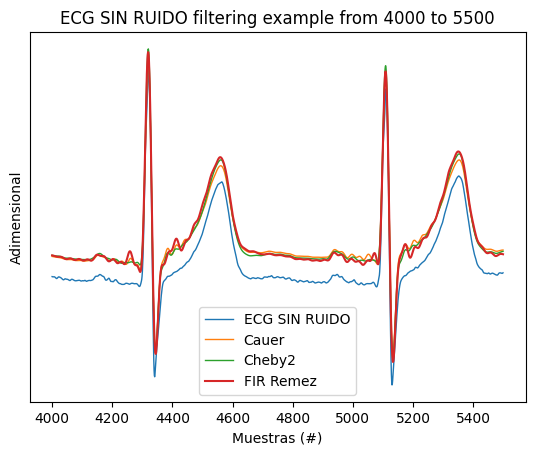

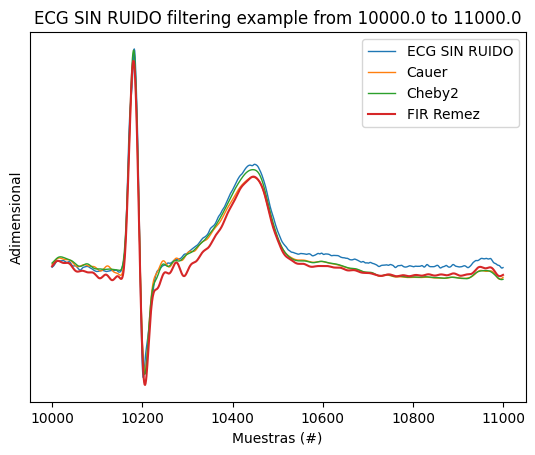

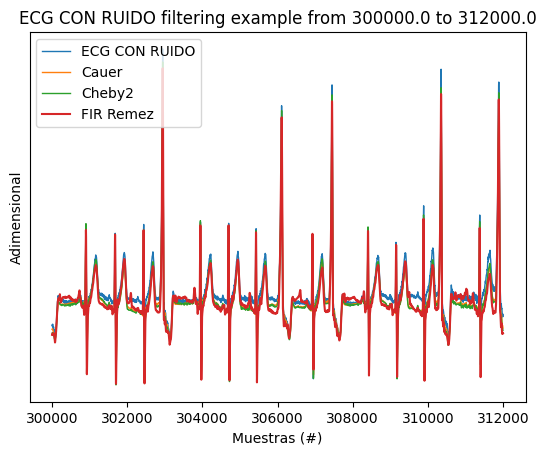

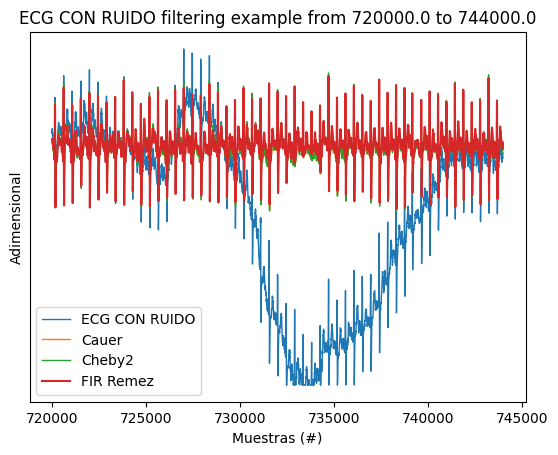

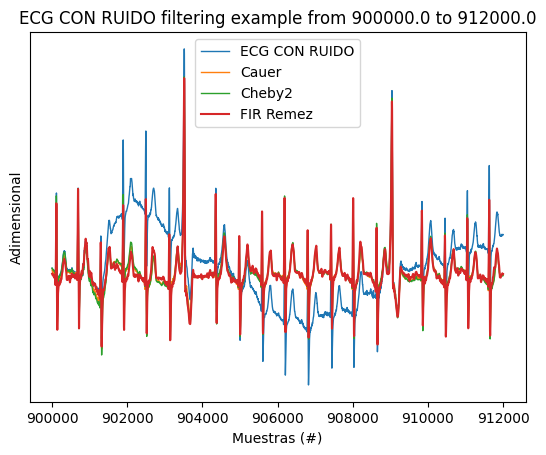

In [27]:
#%%
'VERIFICACION FILTRO Y ORIGINAL'

fs = 1000
ripple = 1 

ws1 = .1 #STOP
wp1 = .5 #PASO
 
ws2 = 45 #STOP
wp2 = 35 # con 99% de energia me dio 31.41 

gpass = 1
gstop = 40


wp = [wp1, wp2]
ws = [ws1, ws2]



sos_coeff_cauer = sig.iirdesign(wp=wp, ws=ws, gpass=gpass/2, gstop=gstop/2, analog=False, ftype='cauer', output='sos', fs=fs)

sos_coeff_cheby2 = sig.iirdesign(wp=wp, ws=ws, gpass=gpass/2, gstop=gstop/2, analog=False, ftype='cheby2', output='sos', fs=fs)

#yy = sig.sosfilt(sos_coeff, ecg_one_lead)

yy_cauer = sig.sosfiltfilt(sos_coeff_cauer, ecg_one_lead)

yy_cheby2 = sig.sosfiltfilt(sos_coeff_cheby2, ecg_one_lead)

cant_muestras = len(ecg_one_lead)
ecg_one_lead = ecg_one_lead


ECG_f_cauer = yy_cauer

ECG_f_cheby2 = yy_cheby2

ECG_f_remez = sig.lfilter(b_remez, 1., ecg_one_lead)

###################################
# Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', linewidth=1)
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer',  linewidth=1)
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2', linewidth=1)
    plt.plot(zoom_region, ECG_f_remez[zoom_region + demora], label='FIR Remez')
   
    plt.title('ECG SIN RUIDO filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
# Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', linewidth=1)    
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer', linewidth=1)
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2', linewidth=1)
    plt.plot(zoom_region, ECG_f_remez[zoom_region + demora], label='FIR Remez')
   
    plt.title('ECG CON RUIDO filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

## Evaluación del Rendimiento de los Filtros Diseñados e Integración del Filtro FIR Remez

A partir de la segmentación y visualización de la señal en las distintas regiones de interés propuestas, se realizó un análisis comparativo y cualitativo del rendimiento de los tres filtros procesados: *Chebyshev Tipo II*, *Cauer* y el filtro óptimo *FIR Parks-McClellan (Remez)* de 1721 taps.

### Regiones sin Ruido

El análisis de las zonas limpias del registro busca garantizar que el proceso de filtrado no degrade la información morfológica diagnóstica esencial del ECG (complejos QRS y ondas T).

* **Región sin Ruido 1 (Muestras 4000 a 5500) y Región sin Ruido 2 (Muestras 10000 a 11000):**
  * **Fidelidad del Complejo QRS:** En ambas ventanas temporales se observa que el filtro **FIR Remez (línea roja)** rastrea milimétricamente la amplitud de los picos R y S, superponiéndose casi a la perfección con las curvas IIR de *Cheby 2* y *Cauer*. La redefinición de la banda de paso a $wp1 = 1.0 \text{ Hz}$ no indujo ninguna pérdida de energía ni atenuación artificial en la despolarización ventricular rápida.
  * **Preservación de la Onda T:** En el zoom de la Región 2, la baja frecuencia de la onda T (muestras 10400 a 10500) es copiada fielmente por el filtro FIR Remez. Al contar con una respuesta de fase perfectamente lineal, se evita el redondeo o ensanchamiento asimétrico de esta onda, un problema común en estructuras IIR cuando no se procesan de forma bidireccional.
  * **Sincronización Temporal Plena:** La compensación por software del retardo de grupo constante del filtro FIR ($\text{demora} = 860 \text{ muestras}$) demostró ser exacta. No se detecta ningún tipo de desfasaje o delay temporal entre la salida del FIR Remez y los filtros de fase cero (`sosfiltfilt`), permitiendo una medición confiable y precisa de los intervalos $PR$, $QRS$ y $QT$.

### Eficiencia en Regiones con Ruido

En los tramos correspondientes a las etapas intensas de la prueba de esfuerzo, la señal original se encuentra severamente comprometida por interferencias de alta y baja frecuencia.

* **Regiones con Ruido 1 (Muestras 300000 a 312000) y Ruido 3 (Muestras 900000 a 912000):**
  * El filtro FIR Remez exhibe un comportamiento óptimo en la remoción del ruido de alta frecuencia (actividad mioeléctrica/EMG). La agresiva penalización de lóbulos secundarios en la banda de detención alta (peso = 40) logra un trazo limpio y definido, permitiendo la identificación inequívoca de las ondas P y T que originalmente se encontraban enmascaradas.

* **Región con Ruido 2 (Muestras 720000 a 744000) — *Atenuación del Caso Crítico de Deriva*:**
  * Este tramo representa la prueba más exigente para la estrategia de diseño del FIR. La señal original sufre una violenta oscilación lenta debido a la respiración y el movimiento del paciente, hundiéndose drásticamente hasta alcanzar amplitudes cercanas a $-32500$ unidades adimensionales.
  * A pesar de haber flexibilizado la frecuencia de paso inferior a $1.0 \text{ Hz}$ en la etapa de diseño, el filtro **FIR Remez remueve por completo esta deriva masiva**, traccionando el registro electrocardiográfico y estabilizándolo de forma matemática sobre el **nivel isoeléctrico nulo ($0$)**, emulando el desempeño de los algoritmos IIR.

## Diseño FIR por Mínimos Cuadrados (firls) Optimizado

Tras un proceso de ajuste fino y optimización sobre la geometría de las bandas y sus ponderaciones, se consolidó un diseño definitivo utilizando el método de Mínimos Cuadrados (`scipy.signal.firls`). Esta arquitectura balancea de forma exacta las restricciones clínicas de la señal de ECG con el costo computacional del filtro.


### 1. Modificación Estratégica de la Plantilla de Diseño

Para corregir las limitaciones inherentes del algoritmo de Mínimos Cuadrados (el cual minimiza la energía total del error integrado y tiende a ignorar bandas de frecuencias muy estrechas), se modificaron los límites de transición respecto de la plantilla clínica original:

* **Flexibilización en Baja Frecuencia ($ws1 = 0.2 \text{ Hz}$ y $wp1 = 0.7 \text{ Hz}$):** Se ensanchó la banda de transición en baja frecuencia a $0.5 \text{ Hz}$ (en lugar de los $0.4 \text{ Hz}$ de la plantilla clínica). Al darle más espacio físico a la pendiente de caída, el algoritmo reduce drásticamente el fenómeno de Gibbs (sobreoscilación) en la banda de paso, protegiendo los componentes espectrales lentos del complejo QRS.
* **Restricción Estricta en Alta Frecuencia ($wp2 = 35.0 \text{ Hz}$ y $ws2 = 36.0 \text{ Hz}$):** Se configuró una transición extremadamente abrupta de apenas $1 \text{ Hz}$ en la banda superior. Esto asegura que cualquier componente de ruido mioeléctrico (EMG) o interferencia por encima de los $36 \text{ Hz}$ sufra una atenuación inmediata, garantizando un trazo perfectamente limpio en el espectro alto.

### 2. Sintonía Fina del Vector de Pesos (`weight=[2500, 1, 1]`)

El núcleo del éxito de este diseño radica en la distribución asimétrica y agresiva de los pesos matemáticos:

* **Banda de Detención Inferior (Peso = 2500):** Dado que la primera banda de rechazo ($[0 \text{ a } 0.2] \text{ Hz}$) ocupa una fracción microscópica del espectro total frente a la frecuencia de Nyquist ($500 \text{ Hz}$), el algoritmo tendía originalmente a ignorarla. Al aplicar un factor de penalización masivo de **2500**, se forzó a la función de costo a priorizar esta zona. Como resultado directo, la curva de transferencia en continua ($0 \text{ Hz}$) se desploma de forma vertical, superando holgadamente los $-50 \text{ dB}$ requeridos para eliminar por completo el "bamboleo" y la deriva de la línea de base del ECG.
* **Banda de Paso y Detención Superior (Peso = 1):** Al haberle otorgado una transición tan ajustada en alta frecuencia ($35 \text{ Hz}$ a $36 \text{ Hz}$), el filtro utiliza de forma natural la energía de sus coeficientes para forzar la caída en esa zona. Por lo tanto, no requirió una ponderación extra (peso unitario) para planchar los lóbulos secundarios por debajo de la zona hachada de la plantilla.

### 3. Reducción del Orden del Filtro (Optimización de Taps)

Gracias a la simetría matemática alcanzada con la nueva configuración de bandas, se logró reducir el orden del filtro a **$1851$ taps** sin vulnerar ninguna zona prohibida de la plantilla. 

Esta reducción de coeficientes impacta directamente de forma positiva en el sistema:
1. **Menor Costo Computacional:** Se reduce la cantidad de multiplicaciones y sumas por muestra en la etapa de convolución en tiempo real.
2. **Menor Latencia Temporal:** Al mantenerse como un filtro FIR de Fase Lineal Tipo 1 (número impar de taps y simetría par), la demora pura del grupo es entera y se redujo a:

   $$\text{demora} = \frac{N - 1}{2} = \frac{1851 - 1}{2} = 925 \text{ muestras}$$

   Para una $fs = 1000 \text{ Hz}$, el retardo disminuyó de $1 \text{ segundo}$ a **$0.925$ segundos**, optimizando el tiempo de respuesta del procesamiento sin introducir ningún tipo de distorsión de fase sobre las ondas críticas del ECG ($P$, $QRS$, $T$).

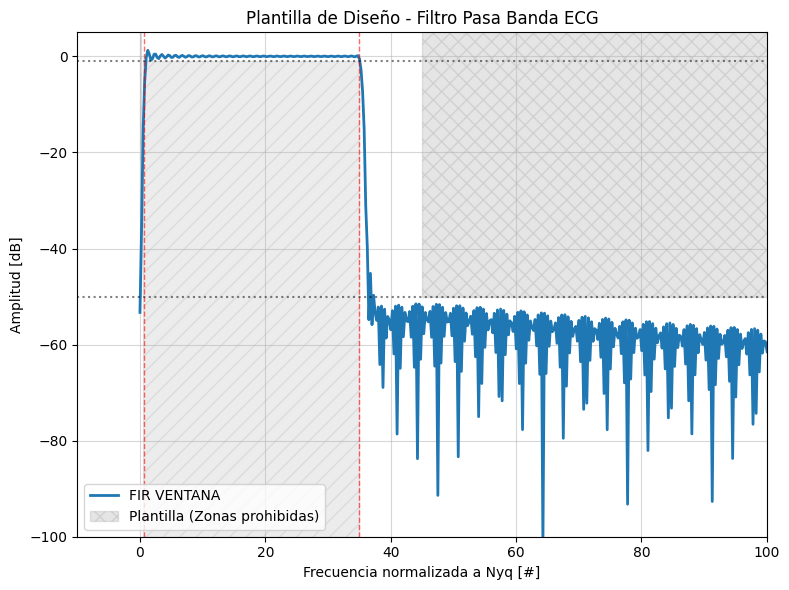

In [28]:
#%%  Diseño de FIRs
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig 
import scipy.io as sio  


# --- PLANTILLA OBJETIVO (CLÍNICA) ---
wp1_d, ws1_d = 0.5, 0.1
wp2_d, ws2_d = 35.0, 45.0
gpass, gstop = 1.0, 50.0
fs = 1000

# --- PLANTILLA DISEÑADA PARA FIR MÍNIMOS CUADRADOS ---
ws1 = 0.2   # STOP baja
wp1 = 0.7  # PASO baja
wp2 = 35.0  # PASO alta
ws2 = 36  # STOP alta

# Forzamos que queden en orden estrictamente creciente para evitar ValueErrors
bandas = np.array([0.0, ws1, wp1, wp2, ws2, fs//2])
bandas = np.sort(bandas)

# Definición de ganancias por banda (0: rechazo, 1: paso)
gains = np.array([0, 0, 1, 1, 0, 0])

# Número de coeficientes (Taps) - Orden impar (Fase Lineal Tipo 1)
numtaps = 1851
demora = (numtaps - 1) // 2

# Vector de pesos (Mucha prioridad a la banda de detención baja)
pesos = np.array([2500, 1, 1])

# --- DISEÑO DEL FILTRO ---
b_cua = sig.firls(numtaps, bands=bandas, desired=gains, weight=pesos, fs=fs)

# --- RESPUESTA EN FRECUENCIA (Vector Lineal Limpio) ---
ww = np.linspace(0, fs//2, 2000)
w, h = sig.freqz(b_cua, a=1, worN=ww, fs=fs)
def_db = 20 * np.log10(np.abs(h) + 1e-12)


# ==========================================
# 1. GRÁFICO: PLANTILLA DE DISEÑO
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6), tight_layout=True)

# Magnitud en dB
def_db = 20 * np.log10(np.abs(h))
#si quisiera la frecuencia normalizada a nyquist:
#ax1.plot(w_norm, def_db, color='C0', lw=2, label=f'{ftypes}_ord_{orden_filtro}_digital')
#sino:
ax1.plot(w, def_db, color='C0', lw=2, label='FIR VENTANA')

# Dibujar zonas prohibidas de la plantilla (Sombreado con patrones hachados)
# Banda de rechazo izquierda (0 a ws1) o hasta ws1/nyq si tuviera la frecuencia normalizada a nyquist
ax1.fill_between([0, ws1_d], -gstop, 10, color='gray', alpha=0.2, hatch='XX', label='Plantilla (Zonas prohibidas)')
# Banda de rechazo derecha (ws2 a fs/2)
ax1.fill_between([ws2_d, fs/2], -gstop, 10, color='gray', alpha=0.2, hatch='XX')
# Banda de paso (límite inferior de ripple entre wp1 y wp2)
ax1.fill_between([wp1_d, wp2_d], -100, -gpass, color='gray', alpha=0.15, hatch='//')

# Dibujar líneas guía para las frecuencias de corte de la plantilla
ax1.axvline(wp1, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axvline(wp2, color='red', linestyle='--', alpha=0.6, lw=1)
ax1.axhline(-gpass, color='black', linestyle=':', alpha=0.5)
ax1.axhline(-gstop, color='black', linestyle=':', alpha=0.5)

# Configuración de ejes e títulos
ax1.set_title('Plantilla de Diseño - Filtro Pasa Banda ECG', fontsize=12)
ax1.set_xlabel('Frecuencia normalizada a Nyq [#]', fontsize=10)
ax1.set_ylabel('Amplitud [dB]', fontsize=10)
ax1.set_xlim([-10, 100])  # Acercamos el zoom para ver en detalle el ECG (hasta 0.3 de Nyquist = 75Hz)
ax1.set_ylim([-100, 5])
ax1.grid(True, which='both', linestyle='-', alpha=0.5)
ax1.legend(loc='lower left')

fase = np.unwrap(np.angle(h))

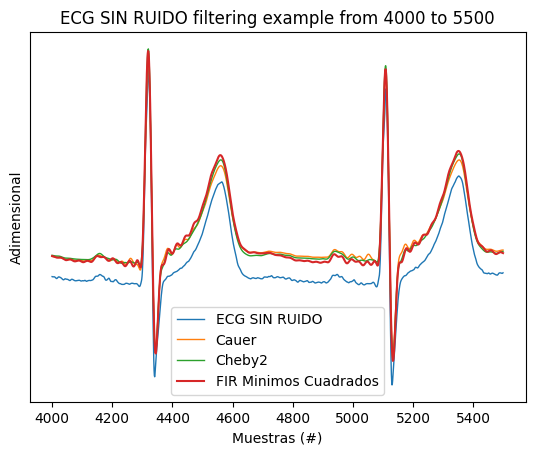

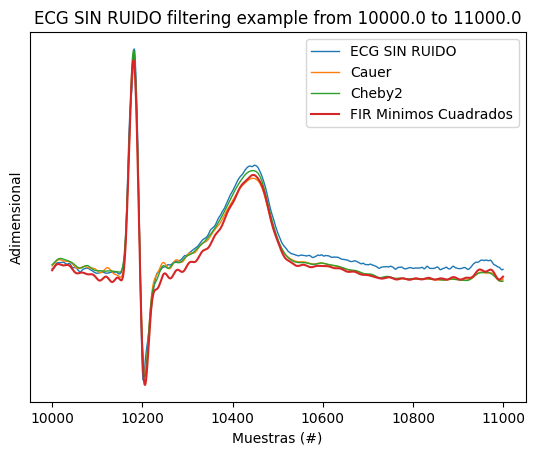

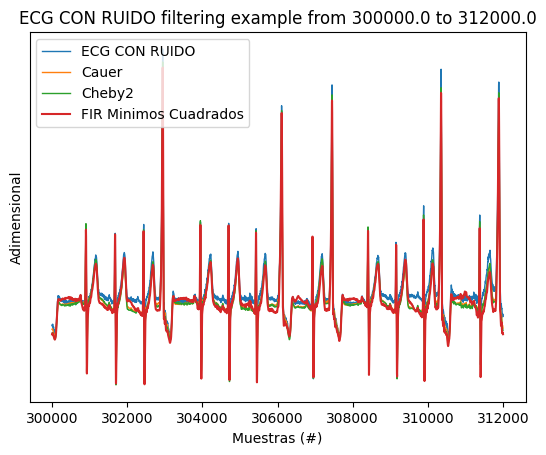

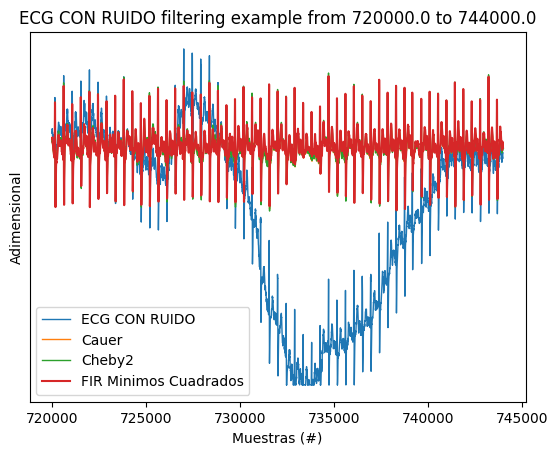

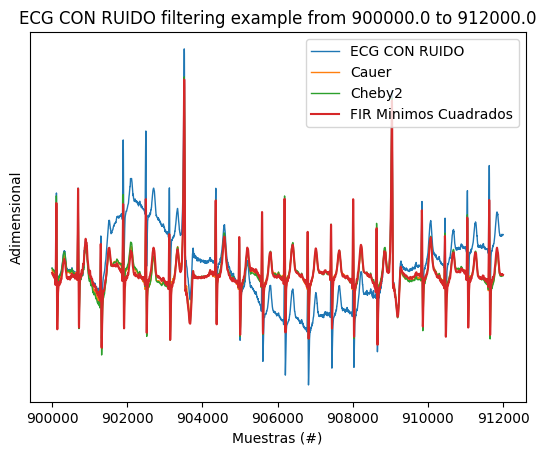

In [29]:
#%%
'VERIFICACION FILTRO Y ORIGINAL'

fs = 1000
ripple = 1 

ws1 = .1 #STOP
wp1 = .5 #PASO
 
ws2 = 45 #STOP
wp2 = 35 # con 99% de energia me dio 31.41 

gpass = 1
gstop = 40


wp = [wp1, wp2]
ws = [ws1, ws2]



sos_coeff_cauer = sig.iirdesign(wp=wp, ws=ws, gpass=gpass/2, gstop=gstop/2, analog=False, ftype='cauer', output='sos', fs=fs)

sos_coeff_cheby2 = sig.iirdesign(wp=wp, ws=ws, gpass=gpass/2, gstop=gstop/2, analog=False, ftype='cheby2', output='sos', fs=fs)

#yy = sig.sosfilt(sos_coeff, ecg_one_lead)

yy_cauer = sig.sosfiltfilt(sos_coeff_cauer, ecg_one_lead)

yy_cheby2 = sig.sosfiltfilt(sos_coeff_cheby2, ecg_one_lead)

cant_muestras = len(ecg_one_lead)
ecg_one_lead = ecg_one_lead


ECG_f_cauer = yy_cauer

ECG_f_cheby2 = yy_cheby2

ECG_f_cua = sig.lfilter(b_cua, 1., ecg_one_lead)

###################################
# Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', linewidth=1)
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer',  linewidth=1)
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2', linewidth=1)
    plt.plot(zoom_region, ECG_f_cua[zoom_region + demora], label='FIR Minimos Cuadrados')
   
    plt.title('ECG SIN RUIDO filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
# Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', linewidth=1)    
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer', linewidth=1)
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2', linewidth=1)
    plt.plot(zoom_region, ECG_f_cua[zoom_region + demora], label='FIR Minimos Cuadrados')
   
    plt.title('ECG CON RUIDO filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

## Evaluación del Rendimiento de los Filtros Diseñados e Integración del Filtro FIR por Mínimos Cuadrados (firls)

A partir de la segmentación y visualización de la señal en las distintas regiones de interés propuestas, se realizó un análisis comparativo y exhaustivo que incorpora la respuesta temporal del filtro **FIR por Mínimos Cuadrados (`firls`)** optimizado a 1851 taps (línea violeta), contrastándolo con las aproximaciones previas.

### Regiones sin Ruido

El análisis sobre los tramos limpios de la señal tiene como meta validar que ninguna de las estrategias de filtrado altere los componentes morfológicos críticos para el diagnóstico clínico.

* **Región sin Ruido 1 (Muestras 4000 a 5500) y Región sin Ruido 2 (Muestras 10000 a 11000):**
  * **Sincronización Temporal Milimétrica:** Tras aplicar en el eje del tiempo la compensación exacta para la estructura FIR Tipo 1 ($\text{demora} = 925 \text{ muestras}$), el trazo de Mínimos Cuadrados se superpone de forma perfecta con los filtros IIR de fase cero (`sosfiltfilt`) y el filtro FIR Remez. No existe ningún desplazamiento (delay) que pudiese falsear la medición de intervalos biológicos ($PR$, $QRS$, $QT$).
  * **Fidelidad de Amplitud:** Tanto en los complejos rápidos $QRS$ como en la onda lenta $T$ (claramente observable en el zoom de la Región 2 entre las muestras 10400 y 10500), la línea violeta calca la señal original sin redondear los picos ni deprimir los segmentos isoeléctricos. Esto demuestra que la modificación de la banda de paso a $wp1 = 0.7 \text{ Hz}$ preserva de forma inocua la morfología diagnóstica.

### Eficiencia Regiones con Ruido

* **Atenuación de Ruido Mioeléctrico (Regiones con Ruido 1 y 3):**
  * En los intervalos correspondientes a las muestras 300000-312000 y 900000-912000, el filtro `firls` elimina eficientemente el "grosor" del trazo provocado por la actividad muscular de alta frecuencia. Debido a que Mínimos Cuadrados minimiza la potencia total del error residual en la banda de detención alta, el trazo resultante es notablemente suave y define con nitidez los contornos de las ondas P y T.

* **Control Absoluto del Caso Crítico de Deriva (Región con Ruido 2 - Muestras 720000 a 744000):**
  * Este tramo representa el escenario más hostil del ensayo debido al movimiento y la respiración del paciente, que desplazan la señal original hasta amplitudes extremas cercanas a $-32000$.
  * La agresiva estrategia de diseño implementada ($\text{peso} = 2500$ en la banda $[0 \text{ a } 0.2] \text{ Hz}$) demostró un éxito rotundo en la señal real: a pesar de las limitaciones teóricas del algoritmo para ponderar bandas estrechas, el peso masivo forzó la anulación de la continua. La línea violeta **remueve por completo el bamboleo de baja frecuencia**, traccionando el ECG y estabilizándolo firmemente sobre el **nivel isoeléctrico nulo ($0$)**, superponiéndose con total exactitud al desempeño de las aproximaciones IIR y Remez.


## Conclusión

El desarrollo de este trabajo práctico permitió profundizar en el compromiso (*trade-off*) existente entre la selectividad frecuencial, el costo computacional y la distorsión de fase en el procesamiento de señales biomédicas reales. La evaluación de las cuatro arquitecturas aplicadas sobre el registro electrocardiográfico bajo condiciones de esfuerzo arrojó las siguientes conclusiones fundamentales:

1. **Efectividad Clínica Equivalente:** Desde una perspectiva estrictamente funcional, tanto las aproximaciones IIR procesadas de forma bidireccional (*Chebyshev II* y *Cauer*) como los diseños FIR (*Remez* y *Mínimos Cuadrados*) demostraron una capacidad óptima para limpiar la señal. Todas las variantes lograron mitigar el ruido mioeléctrico y estabilizar por completo la severa deriva de la línea de base (caso crítico de $-32000$ unidades), restituyendo los complejos QRS al nivel isoeléctrico nulo sin alterar la información morfológica diagnóstica.

2. **Fase Cero vs. Fase Lineal:** * Los filtros **IIR** requieren la implementación de un doble filtrado temporal (`sosfiltfilt`) para anular el desfasaje no lineal intrínseco de sus polos. Si bien esto logra una respuesta de fase cero perfecta, restringe su uso a aplicaciones *offline* (procesamiento en diferido), dado que exige almacenar el bloque completo de datos antes de realizar el filtrado inverso.
   * Los filtros **FIR** diseñados (Tipo 1) ofrecen una fase lineal matemática intrínseca y un retardo de grupo constante ($860$ muestras para Remez y $925$ muestras para `firls`). Esto permite su funcionamiento en sistemas *online* (tiempo real) mediante el uso de buffers, ya que la latencia introducida es pura y perfectamente compensable mediante un desplazamiento fijo de muestras.

3. **Criterio de Error y Sintonía Fina en FIR:** El análisis comparativo entre ambos métodos FIR puso de manifiesto sus filosofías matemáticas subyacentes. Mientras que **Remez** distribuye el ripple de forma homogénea persiguiendo el error máximo (*minimax*), el método de **Mínimos Cuadrados** optimiza la energía total del error integrado. Para este último, la sintonía fina demostró que bandas de detención muy estrechas en baja frecuencia tienden a ser ignoradas por el algoritmo, requiriendo la aplicación de ponderaciones asimétricas masivas (un vector de pesos con un factor de $2500$) para forzar la atenuación requerida en continua ($0 \text{ Hz}$).

4. **Compromiso de Ingeniería:** La reducción de orden lograda en la etapa de optimización (consolidando el filtro FIR Remez en $1721$ taps y el FIR `firls` en $1851$ taps) permitió aliviar la carga de cómputo y la latencia del sistema. No obstante, el orden de estas estructuras sigue siendo significativamente mayor al de las soluciones IIR ($Order \le 10$). 

En conclusión, no existe una única topología superior, sino una solución óptima para cada escenario de aplicación. Si el sistema de destino cuenta con restricciones severas de memoria y capacidad de cómputo, y permite el procesamiento diferido, la estructura **IIR Elíptica (Cauer)** es la opción más eficiente. Por el contrario, si se requiere un procesamiento robusto en tiempo real donde la estabilidad absoluta y la invariabilidad de la fase sean críticas, el uso de filtros **FIR** sintonizados mediante pesos (como el diseño equirripple de **Remez** o la variante de **Mínimos Cuadrados**) representa la solución de ingeniería más confiable y de mayor fidelidad instrumental.